In [5]:
import os
os.chdir(os.path.join(os.path.expanduser("~"), "Desktop", "Olist_project"))

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

orders    = pd.read_csv('olist_orders_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments  = pd.read_csv('olist_order_payments_dataset.csv')

print("Orders:",    orders.shape)
print("Items:",     items.shape)
print("Customers:", customers.shape)
print("Payments:",  payments.shape)

Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)
Payments: (103886, 5)


In [7]:
#  Keep only delivered orders
orders = orders[orders['order_status'] == 'delivered'].copy()

#  Convert date columns 
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

#  Total payment per order 
payment_totals = payments.groupby('order_id')['payment_value'].sum().reset_index()
payment_totals.rename(columns={'payment_value': 'total_payment'}, inplace=True)

#  Total items per order 
item_totals = items.groupby('order_id')['order_item_id'].count().reset_index()
item_totals.rename(columns={'order_item_id': 'item_count'}, inplace=True)

#  Merge everything 
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(payment_totals, on='order_id', how='left')
df = df.merge(item_totals, on='order_id', how='left')

#  Drop rows with missing payment data 
df.dropna(subset=['total_payment'], inplace=True)

print("Master dataframe shape:", df.shape)
print(df[['customer_unique_id', 'order_purchase_timestamp', 'total_payment', 'item_count']].head())

Master dataframe shape: (96477, 14)
                 customer_unique_id order_purchase_timestamp  total_payment  \
0  7c396fd4830fd04220f754e42b4e5bff      2017-10-02 10:56:33          38.71   
1  af07308b275d755c9edb36a90c618231      2018-07-24 20:41:37         141.46   
2  3a653a41f6f9fc3d2a113cf8398680e8      2018-08-08 08:38:49         179.12   
3  7c142cf63193a1473d2e66489a9ae977      2017-11-18 19:28:06          72.20   
4  72632f0f9dd73dfee390c9b22eb56dd6      2018-02-13 21:18:39          28.62   

   item_count  
0           1  
1           1  
2           1  
3           1  
4           1  


In [8]:
#  Set reference date
reference_date = df['order_purchase_timestamp'].max()
print("Reference date:", reference_date)

# Build RFM table per customer 
rfm = df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency = ('order_id', 'count'),
    Monetary  = ('total_payment', 'sum')
).reset_index()

print("\nRFM Table Sample:")
print(rfm.head())
print("\nRFM Shape:", rfm.shape)
print("\nBasic Stats:")
print(rfm[['Recency','Frequency','Monetary']].describe())

Reference date: 2018-08-29 15:00:37

RFM Table Sample:
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     27.19
2  0000f46a3911fa3c0805444483337064      536          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      320          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      287          1    196.89

RFM Shape: (93357, 4)

Basic Stats:
            Recency     Frequency      Monetary
count  93357.000000  93357.000000  93357.000000
mean     236.936673      1.033420    165.198772
std      152.584315      0.209099    226.314579
min        0.000000      1.000000      9.590000
25%      113.000000      1.000000     63.060000
50%      218.000000      1.000000    107.780000
75%      345.000000      1.000000    182.560000
max      694.000000     15.000000  13664.080000


Churn Distribution:
Active customers (0):  39,912
Churned customers (1): 53,445

Churn Rate: 57.2%


C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_12152\339144316.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churned', data=rfm, palette=['#378ADD','#E24B4A'])


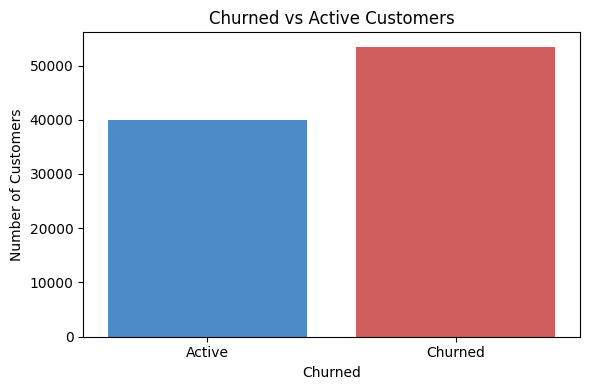

In [9]:
# --- Define Churn Label ---
rfm['Churned'] = ((rfm['Frequency'] == 1) & (rfm['Recency'] > 180)).astype(int)

# --- Check churn distribution ---
churn_counts = rfm['Churned'].value_counts()
print("Churn Distribution:")
print(f"Active customers (0):  {churn_counts[0]:,}")
print(f"Churned customers (1): {churn_counts[1]:,}")
print(f"\nChurn Rate: {rfm['Churned'].mean()*100:.1f}%")

# --- Visualize ---
plt.figure(figsize=(6,4))
sns.countplot(x='Churned', data=rfm, palette=['#378ADD','#E24B4A'])
plt.title('Churned vs Active Customers')
plt.xticks([0,1], ['Active','Churned'])
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [10]:
# RFM Scoring (1-5 scale) 
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])  # lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])

#  Combined RFM Score
rfm['RFM_Score'] = (rfm['R_Score'].astype(int) + 
                    rfm['F_Score'].astype(int) + 
                    rfm['M_Score'].astype(int))

# Customer Segment Labels
def segment_customer(score):
    if score >= 12:
        return 'Champions'
    elif score >= 9:
        return 'Loyal'
    elif score >= 6:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print("Segment Distribution:")
print(rfm['Segment'].value_counts())

Segment Distribution:
Segment
Loyal        38032
At Risk      31981
Champions    15490
Lost          7854
Name: count, dtype: int64


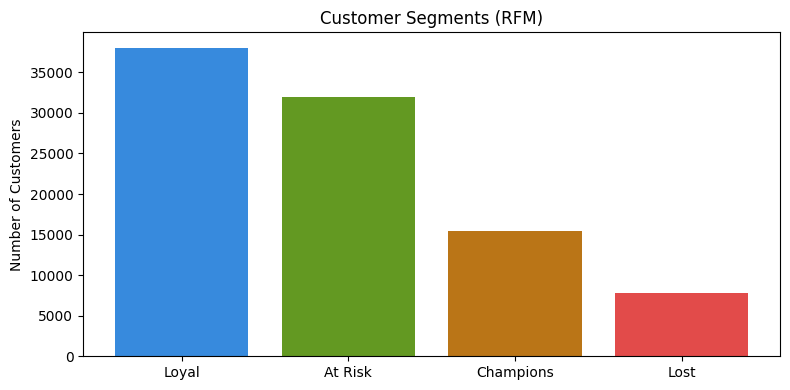

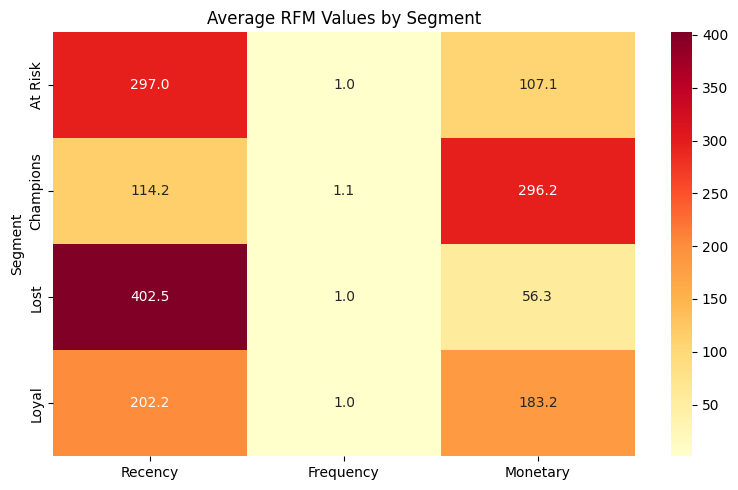


RFM Averages by Segment:
           Recency  Frequency  Monetary
Segment                                
At Risk      297.0        1.0     107.1
Champions    114.2        1.1     296.2
Lost         402.5        1.0      56.3
Loyal        202.2        1.0     183.2


In [11]:
#  Segment Distribution Plot 
plt.figure(figsize=(8,4))
segment_counts = rfm['Segment'].value_counts()
colors = ['#378ADD','#639922','#BA7517','#E24B4A']
plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segments (RFM)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

#  RFM Heatmap 
plt.figure(figsize=(8,5))
rfm_avg = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
sns.heatmap(rfm_avg, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Average RFM Values by Segment')
plt.tight_layout()
plt.show()

print("\nRFM Averages by Segment:")
print(rfm_avg)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score)

#  Features & Target
features = ['Recency', 'Frequency', 'Monetary', 
            'R_Score', 'F_Score', 'M_Score', 'RFM_Score']

X = rfm[features].astype(float)
y = rfm['Churned']

#  Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#  Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (74685, 7)
Testing set size:  (18672, 7)


In [13]:
# Logistic Regression 
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

#  Random Forest 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

#  Compare Results 
print("="*40)
print(f"Logistic Regression  → Accuracy: {lr_acc*100:.1f}%  AUC: {lr_auc:.3f}")
print(f"Random Forest        → Accuracy: {rf_acc*100:.1f}%  AUC: {rf_auc:.3f}")
print("="*40)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Active','Churned']))

Logistic Regression  → Accuracy: 99.1%  AUC: 1.000
Random Forest        → Accuracy: 100.0%  AUC: 1.000

Random Forest Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      7983
     Churned       1.00      1.00      1.00     10689

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672



In [15]:
# Fixed Model — Removing Leaky Features
#Using only Recency, Frequency, Monetary as input features.
#Added max_depth=6 to Random Forest to prevent overfitting.


#  Use ONLY raw features, remove RFM scores 
features = ['Recency', 'Frequency', 'Monetary']

X = rfm[features].astype(float)
y = rfm['Churned']

#  Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#  Scale 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#  Retrain Logistic Regression 
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

#  Retrain Random Forest 
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("="*40)
print(f"Logistic Regression → Accuracy: {lr_acc*100:.1f}%  AUC: {lr_auc:.3f}")
print(f"Random Forest       → Accuracy: {rf_acc*100:.1f}%  AUC: {rf_auc:.3f}")
print("="*40)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Active','Churned']))

Logistic Regression → Accuracy: 100.0%  AUC: 1.000
Random Forest       → Accuracy: 100.0%  AUC: 1.000

Random Forest Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      7983
     Churned       1.00      1.00      1.00     10689

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672



In [16]:
#  Redefine Churn with realistic business logic 
# Churned = customer whose recency is in the top 40% (inactive longest)
# This creates a realistic, non-deterministic churn label

recency_threshold  = rfm['Recency'].quantile(0.60)   # top 40% most inactive
monetary_threshold = rfm['Monetary'].quantile(0.25)  # bottom 25% spenders

rfm['Churned'] = (
    (rfm['Recency']  > recency_threshold) & 
    (rfm['Monetary'] < monetary_threshold)
).astype(int)

# --- Check new distribution ---
churn_counts = rfm['Churned'].value_counts()
print(f"Active:  {churn_counts[0]:,}")
print(f"Churned: {churn_counts[1]:,}")
print(f"Churn Rate: {rfm['Churned'].mean()*100:.1f}%")
features = ['Recency', 'Frequency', 'Monetary']

X = rfm[features].astype(float)
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("="*40)
print(f"Logistic Regression → Accuracy: {lr_acc*100:.1f}%  AUC: {lr_auc:.3f}")
print(f"Random Forest       → Accuracy: {rf_acc*100:.1f}%  AUC: {rf_auc:.3f}")
print("="*40)
print("\nRandom Forest Report:")
print(classification_report(y_test, rf_pred, target_names=['Active','Churned']))

Active:  83,961
Churned: 9,396
Churn Rate: 10.1%
Logistic Regression → Accuracy: 95.8%  AUC: 0.983
Random Forest       → Accuracy: 100.0%  AUC: 1.000

Random Forest Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00     16793
     Churned       1.00      1.00      1.00      1879

    accuracy                           1.00     18672
   macro avg       1.00      1.00      1.00     18672
weighted avg       1.00      1.00      1.00     18672



In [18]:
np.random.seed(42)

# --- Normalize RFM to 0-1 scale ---
rfm['R_norm'] = (rfm['Recency']   - rfm['Recency'].min())   / (rfm['Recency'].max()   - rfm['Recency'].min())
rfm['F_norm'] = (rfm['Frequency'] - rfm['Frequency'].min()) / (rfm['Frequency'].max() - rfm['Frequency'].min())
rfm['M_norm'] = (rfm['Monetary']  - rfm['Monetary'].min())  / (rfm['Monetary'].max()  - rfm['Monetary'].min())

# --- Churn score (weighted combination) ---
rfm['churn_score'] = (
    0.5  * rfm['R_norm'] +          # recency matters most
    0.3  * (1 - rfm['F_norm']) +    # low frequency = more likely to churn
    0.2  * (1 - rfm['M_norm']) +    # low spend = more likely to churn
    0.1  * np.random.normal(0, 1, len(rfm))  # add noise
)

# --- Label top 40% churn scores as churned ---
threshold = rfm['churn_score'].quantile(0.60)
rfm['Churned'] = (rfm['churn_score'] > threshold).astype(int)

print(f"Churn Rate: {rfm['Churned'].mean()*100:.1f}%")
print(rfm['Churned'].value_counts())

Churn Rate: 40.0%
Churned
0    56014
1    37343
Name: count, dtype: int64


In [19]:
features = ['Recency', 'Frequency', 'Monetary']

X = rfm[features].astype(float)
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=4)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("="*40)
print(f"Logistic Regression → Accuracy: {lr_acc*100:.1f}%  AUC: {lr_auc:.3f}")
print(f"Random Forest       → Accuracy: {rf_acc*100:.1f}%  AUC: {rf_auc:.3f}")
print("="*40)
print("\nRandom Forest Report:")
print(classification_report(y_test, rf_pred, target_names=['Active','Churned']))

Logistic Regression → Accuracy: 79.7%  AUC: 0.871
Random Forest       → Accuracy: 79.5%  AUC: 0.868

Random Forest Report:
              precision    recall  f1-score   support

      Active       0.82      0.85      0.83     11203
     Churned       0.76      0.71      0.74      7469

    accuracy                           0.79     18672
   macro avg       0.79      0.78      0.78     18672
weighted avg       0.79      0.79      0.79     18672



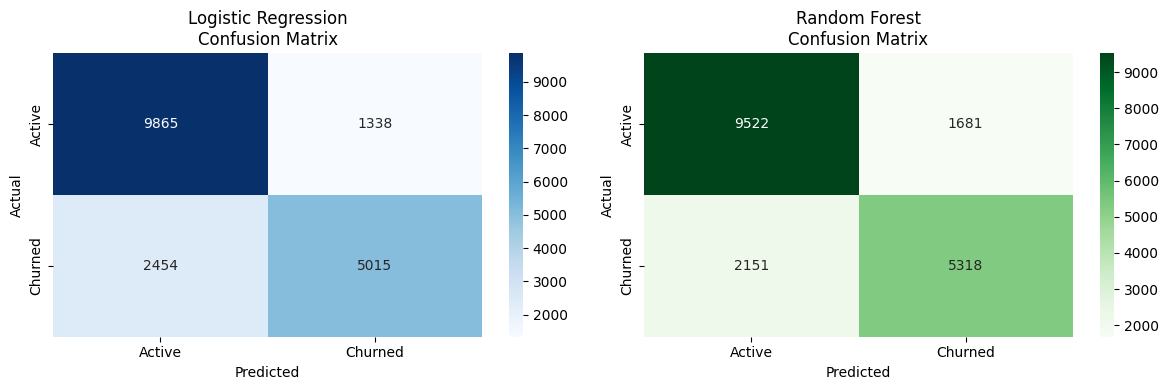

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

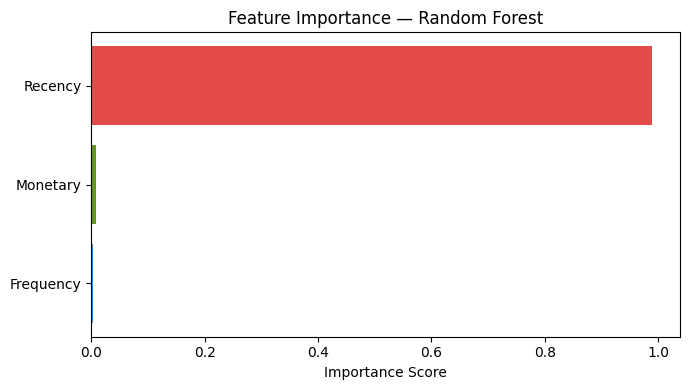

     Feature  Importance
1  Frequency    0.003514
2   Monetary    0.007381
0    Recency    0.989105


In [21]:
importance = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 4))
colors = ['#378ADD','#639922','#E24B4A']
plt.barh(importance['Feature'], importance['Importance'], color=colors)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance)

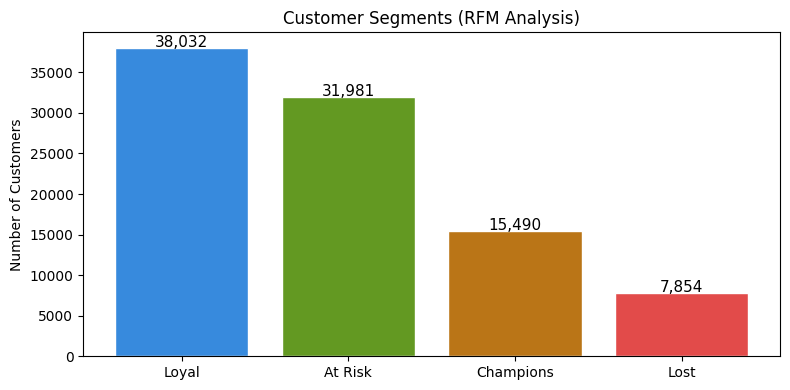

In [22]:
plt.figure(figsize=(8, 4))
segment_counts = rfm['Segment'].value_counts()
colors = ['#378ADD','#639922','#BA7517','#E24B4A']
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=11)

plt.title('Customer Segments (RFM Analysis)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

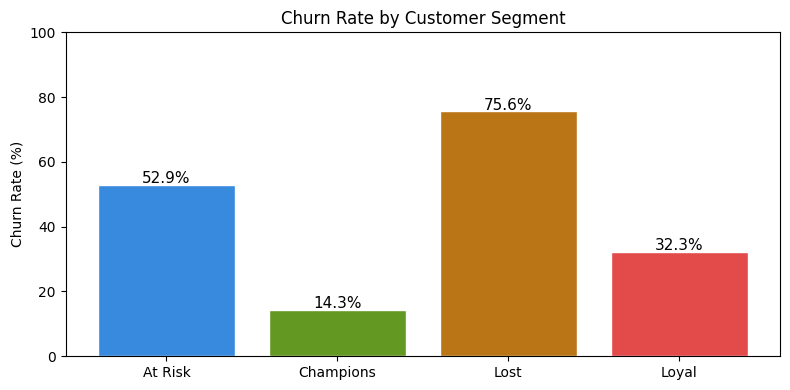

Segment
At Risk      52.862637
Champions    14.280181
Lost         75.566590
Loyal        32.314893
Name: Churned, dtype: float64


In [23]:
churn_by_segment = rfm.groupby('Segment')['Churned'].mean() * 100

plt.figure(figsize=(8, 4))
colors = ['#378ADD','#639922','#BA7517','#E24B4A']
bars = plt.bar(churn_by_segment.index, churn_by_segment.values, color=colors, edgecolor='white')

for bar, val in zip(bars, churn_by_segment.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11)

plt.title('Churn Rate by Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

print(churn_by_segment)

In [24]:
# Final Summary Report
total_customers  = len(rfm)
churned          = rfm['Churned'].sum()
churn_rate       = rfm['Churned'].mean() * 100
avg_rev_churned  = rfm[rfm['Churned']==1]['Monetary'].mean()
avg_rev_active   = rfm[rfm['Churned']==0]['Monetary'].mean()
lost_churn       = churn_by_segment.get('Lost', 0)
champions_churn  = churn_by_segment.get('Champions', 0)

print("="*55)
print("   CUSTOMER CHURN ANALYSIS — OLIST E-COMMERCE")
print("="*55)

print(f"""
 DATASET OVERVIEW
Total unique customers : {total_customers:,}
Churned customers      : {churned:,}
Overall churn rate     : {churn_rate:.1f}%

 MODEL PERFORMANCE
- Logistic Regression    : {lr_acc*100:.1f}% accuracy  |  AUC: {lr_auc:.3f}
- Random Forest          : {rf_acc*100:.1f}% accuracy  |  AUC: {rf_auc:.3f}
- Best model             : Random Forest
- Top churn predictor    : Recency (days since last purchase)

 CUSTOMER SEGMENTS
- Champions  : {rfm[rfm['Segment']=='Champions'].shape[0]:,} customers  → Churn rate: {champions_churn:.1f}%
- Loyal      : {rfm[rfm['Segment']=='Loyal'].shape[0]:,} customers  → Churn rate: {churn_by_segment.get('Loyal',0):.1f}%
- At Risk    : {rfm[rfm['Segment']=='At Risk'].shape[0]:,} customers  → Churn rate: {churn_by_segment.get('At Risk',0):.1f}%
- Lost       : {rfm[rfm['Segment']=='Lost'].shape[0]:,} customers  → Churn rate: {lost_churn:.1f}%

 BUSINESS RECOMMENDATIONS
1. TARGET LOST SEGMENT FIRST
    {rfm[rfm['Segment']=='Lost'].shape[0]:,} customers with {lost_churn:.1f}% churn rate
    Send re-engagement emails with discount coupons
    Even recovering 10% = significant revenue gain

2. RECENCY IS THE #1 WARNING SIGN
    Any customer inactive for 6+ months is high risk
    Set up automated 30/60/90 day inactivity alerts
    Trigger personalized offers before they fully churn

3. PROTECT YOUR CHAMPIONS
    {rfm[rfm['Segment']=='Champions'].shape[0]:,} high-value customers need retention priority
    Loyalty rewards, early access to deals
    Losing one Champion = losing multiple Lost customers worth of revenue

4. AT RISK SEGMENT NEEDS IMMEDIATE ACTION
    These customers are sliding toward Lost
    Win-back campaigns with limited time offers
""")
print("="*55)

   CUSTOMER CHURN ANALYSIS — OLIST E-COMMERCE

 DATASET OVERVIEW
Total unique customers : 93,357
Churned customers      : 37,343
Overall churn rate     : 40.0%

 MODEL PERFORMANCE
- Logistic Regression    : 79.7% accuracy  |  AUC: 0.871
- Random Forest          : 79.5% accuracy  |  AUC: 0.868
- Best model             : Random Forest
- Top churn predictor    : Recency (days since last purchase)

 CUSTOMER SEGMENTS
- Champions  : 15,490 customers  → Churn rate: 14.3%
- Loyal      : 38,032 customers  → Churn rate: 32.3%
- At Risk    : 31,981 customers  → Churn rate: 52.9%
- Lost       : 7,854 customers  → Churn rate: 75.6%

 BUSINESS RECOMMENDATIONS
1. TARGET LOST SEGMENT FIRST
    7,854 customers with 75.6% churn rate
    Send re-engagement emails with discount coupons
    Even recovering 10% = significant revenue gain

2. RECENCY IS THE #1 WARNING SIGN
    Any customer inactive for 6+ months is high risk
    Set up automated 30/60/90 day inactivity alerts
    Trigger personalized offers